## CLASSIFICAÇÃO

### Tarefa: Classificar Homer e Bart com rede neural densa
Olá!

Nas primeiras aulas sobre as redes neurais convolucionais eu mostrei uma forma que pode ser utilizada para a classificação de imagens, que é:

Analisar as principais características de cada classe, construir um extrator de características, executar esse extrator em cada imagem e por fim, construir uma base de dados utilizando essas características

Para revisar esse processo, considere a imagem abaixo na qual escolhemos três características para o Bart e três características para o Homer (somente relacionadas a cores)

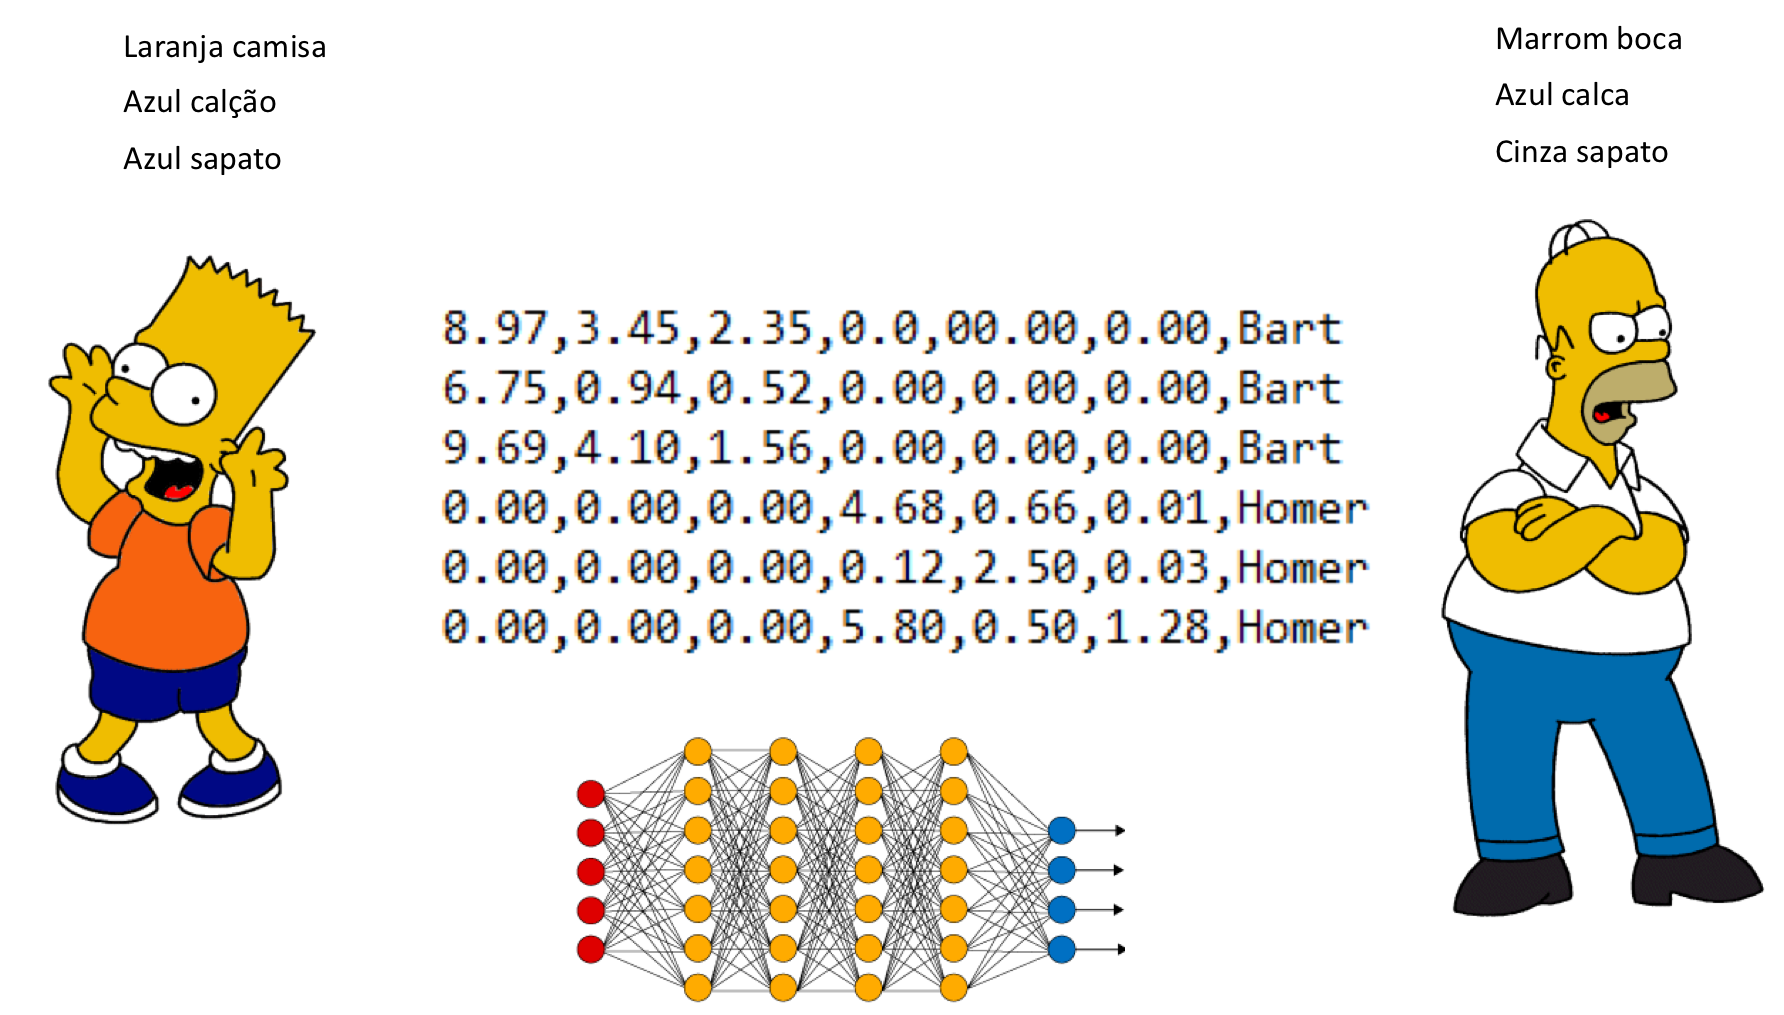

Conforme eu comentei nas aulas teóricas, no meu outro curso (Machine Learning e Data Science com Weka e Java) nós desenvolvemos este extrator de características e fizemos a geração da base de dados, a qual você utilizará nesta tarefa para a construção da rede neural densa (arquivo personagens.csv). Siga as seguintes instruções:

Caso não lembre esses processos, sugiro que você assista novamente a primeira aula sobre as redes neurais convolucionais

Nesta tarefa você NÃO deve construir uma rede neural convolucional, mas <b>sim uma rede neural densa simples</b>. A ideia é primeiro fazer experimentos com com essa técnica de extração de características para depois construirmos a <b>rede neural convolucional</b> e compararmos os resultados

No arquivo personagens.csv temos 293 registros (imagens), 169 da classe Homer e 124 da classe Bart. Para fazer os experimentos você deve utilizar 75% da base para treinamento e 25% para teste, utilizando a função train_test_split para divisão da base de dados



# Tarefa: Homer e Bart com Rede Neural Densa

## Etapa 1: Importação das bibliotecas

In [1]:
# bibliotecas
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import torch
from torch import nn, optim
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
torch.__version__

'2.9.1+cpu'

## Etapa 2: Base de dados

In [2]:
# para sempre gerar o mesmo valor
torch.manual_seed(123)
np.random.seed(124)

In [3]:
base = pd.read_csv('personagens.csv')
base.tail(2)

,laranja_camisa_bart,azul_calcao_bart,azul_sapato_bart,marrom_boca_homer,azul_calca_homer,cinza_sapato_homer,classe
291,0.0,0.0,0.0,0.000000,1.429134,0.017013,Homer
292,0.0,0.0,0.0,13.744248,0.853902,0.063546,Homer


In [4]:
base.columns[0:6] # previsores

Index(['laranja_camisa_bart', 'azul_calcao_bart', 'azul_sapato_bart',
       'marrom_boca_homer', 'azul_calca_homer', 'cinza_sapato_homer'],
      dtype='object')

In [5]:
base.columns[6:7] # classe é o alvo que desejo prever

Index(['classe'], dtype='object')

In [6]:
previsores = base.iloc[:, 0:6].values
classe = base.iloc[:, 6].values

In [7]:
# 1. Cria uma instância do codificador (LabelEncoder)
# Ele serve para mapear categorias de texto (ex: 'Cão', 'Gato', ou Homer ou Bart) em números (ex: 0, 1)
encoder = LabelEncoder()

# 2. O comando fit_transform faz duas coisas ao mesmo tempo:
# fit: Ele lê a coluna 'classe' e aprende quais são os nomes únicos (as etiquetas).
# transform: Ele substitui cada nome pelo seu respectivo número (geralmente em ordem alfabética).
# Exemplo: Se 'classe' era ['Gato', 'Cão', 'Gato'], agora será [1, 0, 1]
classe = encoder.fit_transform(classe)

In [8]:
# train_test_split: Divide o dataset em quatro partes para validar o modelo
# previsores: São as características (X) que a IA usa para aprender (Ex: 'laranja_camisa_bart', 'azul_calcao_bart', 'azul_sapato_bart',
#       'marrom_boca_homer', 'azul_calca_homer', 'cinza_sapato_homer')
# classe: É a resposta correta (y) que queremos prever (Ex: classe = personagem)

# test_size=0.25: Define que 25% dos dados serão guardados para o TESTE final
# Consequentemente, 75% dos dados serão usados para o TREINAMENTO

# Retorno das variáveis:
# previsores_treinamento: Dados de entrada para o treino
# previsores_teste: Dados de entrada para o teste (IA nunca viu esses)
# classe_treinamento: Respostas corretas do treino
# classe_teste: Respostas corretas do teste (Gabarito do professor)
previsores_treinamento, previsores_teste, classe_treinamento, classe_teste = train_test_split(
    previsores, classe, test_size=0.25
)

In [9]:
# o PyTorch exige um formato especial chamado Tensor.
#Além disso, ele é muito exigente com o tipo de dado (precisa ser float para calcular os pesos).

# 1. np.array(): Garante que os dados do Pandas/Lista sejam convertidos para um array NumPy
# 2. torch.tensor(): Transforma o array NumPy em um Tensor do PyTorch (formato obrigatório para redes neurais)
# 3. dtype = torch.float: Define que os números serão decimais (float32). 
# Redes neurais precisam de float para realizar os cálculos matemáticos de gradiente.

# Converte os dados de entrada (X) em tensores para o treinamento
previsores_treinamento = torch.tensor(np.array(previsores_treinamento), dtype = torch.float)

# Converte as respostas (y) em tensores para o treinamento
classe_treinamento = torch.tensor(np.array(classe_treinamento), dtype = torch.float)

A "Ponte" NumPy: O PyTorch e o NumPy são "melhores amigos". A forma mais segura de criar um tensor sem erros de memória é transformando o dado em um array NumPy primeiro.

O tipo de dado (Float): Por padrão, o Python pode ler números inteiros (como o 0 e 1 do seu LabelEncoder) como int64. Porém, as funções matemáticas das redes neurais (como a retropropagação) exigem float32. Se esquecermos o dtype, o PyTorch pode dar um erro de "RuntimeError: expected scalar type Float but found Long".

💡 Uma observação importante
Se você estiver fazendo uma classificação com mais de duas classes (como as 7 árvores que vimos antes) e for usar a função de erro CrossEntropyLoss, a sua classe_treinamento (o y) geralmente precisa ser do tipo torch.Long (inteiros), enquanto os previsores continuam como float.

In [10]:
# organizamos em pequenos pacotes.

# 1. TensorDataset: Agrupa os seus previsores (X) e suas classes (y) em um único objeto.
# É como se ele 'grampeasse' cada linha de características com sua resposta correta,
# garantindo que elas não se percam ou se misturem durante o treino.
dataset = torch.utils.data.TensorDataset(previsores_treinamento, classe_treinamento)

# 2. DataLoader: Cria um 'carregador' inteligente para o dataset.
# batch_size = 10: Divide os dados em grupos de 10 em 10. A rede neural vai olhar 10 exemplos,
# calcular o erro, ajustar os pesos e só então passar para os próximos 10.
# shuffle = True: Embaralha os dados a cada nova época de treinamento. Isso é vital para que
# a rede não aprenda a ordem dos dados, mas sim os padrões reais.
train_loader = torch.utils.data.DataLoader(dataset, batch_size = 10, shuffle = True)

## Etapa 3: Construção do modelo

### arquitetura da sua rede neural

O nn.Sequential funciona como uma "esteira de produção": os dados entram por um lado, passam por várias transformações em sequência e saem do outro lado como uma previsão.

In [11]:
(6+1)/2 # quantidade de neurônios para as camadas ocultas ideais ou recomendadas

3.5

In [12]:
# nn.Sequential: Cria um recipiente que executa as camadas na ordem em que foram escritas.
classificador = nn.Sequential(
    
    # 1ª Camada Oculta: Recebe 6 entradas (seus previsores) e entrega 4 neurônios.
    # O '6' deve ser exatamente o número de colunas do meu X_train ou previsores_treinamento.
    nn.Linear(6, 4),
    # Função de Ativação ReLU: Introduz não-linearidade, permitindo que a rede
    # aprenda padrões complexos (basicamente transforma valores negativos em zero).
    nn.ReLU(),

    # 2ª Camada Oculta: Recebe os 4 dados da camada anterior e mantém 4 neurônios.
    nn.Linear(4, 4),
    nn.ReLU(),

    # Camada de Saída: Recebe 4 dados e reduz para apenas 1 neurônio final.
    nn.Linear(4, 1),
    
    # Sigmoid: Transforma o número final em uma probabilidade entre 0 e 1.
    # Ideal para classificação binária (ex: Bart ou Homer, Sim ou Não).
    nn.Sigmoid()
)

Os Números (6, 4, 1): * O 6 indica que seu dataset tem 6 características (ex: altitude, tipo de solo, etc).

O 4 é uma escolha sua (hiperparâmetro). Você definiu camadas finas para manter o modelo leve.

O 1 no final é porque você quer uma única resposta: a probabilidade de pertencer a uma classe.

Por que ReLU? Sem ela, a sua rede neural seria apenas uma equação matemática simples. A ReLU dá "poder" à rede para aprender curvas e comportamentos que não são linhas retas.

Por que Sigmoid no final? Como você está usando BCELoss (provavelmente) e quer saber se é classe 0 ou 1, a Sigmoid "esmaga" qualquer valor que venha da rede para dentro do intervalo [0, 1].

$\begin{array}{|c|c|c|c|}
\hline
\textbf{Função} & \textbf{Fórmula} & \textbf{Intervalo de saída} & \textbf{Uso comum} \\
\hline
\text{Sigmoid} & 
\sigma(x) = \frac{1}{1 + e^{-x}} & (0, 1) & \text{Classificação binária} \\
\hline
\text{Tanh} & 
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} & (-1, 1) & \text{Camadas ocultas (alternativa ao ReLU)} \\
\hline
\text{ReLU} & 
f(x) = \max(0, x) & [0, \infty) & \text{Camadas ocultas (mais usado)} \\
\hline
\text{Leaky ReLU} & 
f(x) = \begin{cases}
x & \text{se } x > 0 \\
\alpha x & \text{se } x \leq 0
\end{cases} & (-\infty, \infty) & \text{Evita neurônios mortos no ReLU} \\
\hline
\text{ELU} & 
f(x) = \begin{cases}
x & \text{se } x > 0 \\
\alpha(e^x - 1) & \text{se } x \leq 0
\end{cases} & (-\alpha, \infty) & \text{Camadas ocultas, alternativa ao ReLU} \\
\hline
\text{Softmax} & 
f(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}} & (0, 1), \ \sum f(x_i) = 1 & \text{Classificação multiclasse} \\
\hline
\end{array}$

# 🔹 O ReLU (Rectified Linear Unit)

Características:

Simples, rápido de calcular.

Resolve o problema do vanishing gradient (quando os gradientes ficam quase zero em sigmoides/tanh).

Muito usado em camadas ocultas.

⚠️ Problema: pode causar “neurônios mortos” (quando muitos valores ficam ≤ 0 e nunca mais reativam).


# 🔹 1. Sigmoid

Saída entre 0 e 1 → ideal para classificação binária.

Problema: saturação → gradientes muito pequenos para valores extremos.

# 🔹 2. Tanh (Tangente Hiperbólica)

Saída entre -1 e 1.

Centraliza os dados em torno de 0 (melhor que sigmoid).

Mas ainda sofre com vanishing gradient.

# 🔹 3. Leaky ReLU

Variante do ReLU que deixa um “vazamento” para valores negativos.

Resolve o problema de neurônios mortos.

#🔹 4. ELU (Exponential Linear Unit)

Parecido com ReLU, mas valores negativos seguem uma curva exponencial suave.
Melhora a aprendizagem, mas é mais caro computacionalmente.

#🔹 5. Softmax

Transforma um vetor de valores em probabilidades que somam 1.

Usado em classificação multiclasse (saída com várias categorias).



🔹 Resumo, o uso mais comum:

Camadas ocultas → ReLU, Leaky ReLU, às vezes Tanh/ELU.

Saída binária → Sigmoid.

Saída multiclasse → Softmax.

### valores numéricos de séries temporais (ex: vendas, demanda, preços), o ideal é:

- ReLU nas camadas ocultas

- Linear (sem ativação) na saída.

### valores numéricos de séries temporais (ex: vendas, demanda, preços), o ideal é:

- ReLU nas camadas ocultas

- Linear (sem ativação) na saída.

In [13]:
# 1. criterion (Critério de Erro): Define a função de perda (Loss Function).
# BCELoss (Binary Cross Entropy Loss): É a medida de erro padrão para classificação binária (0 ou 1).
# Ela calcula a "distância" entre a previsão da rede (ex: 0.7) e a resposta real (ex: 1.0).
# Quanto maior essa distância, maior o erro que a rede precisa corrigir.
criterion = nn.BCELoss()

# 2. optimizer (Otimizador): É o algoritmo que ajusta os pesos da rede.
# optim.Adam: Um dos otimizadores mais modernos e eficientes. Ele ajusta a "velocidade" 
# do aprendizado automaticamente para cada neurônio.
# classificador.parameters(): Informa ao Adam quais são os pesos e conexões da rede
# que ele tem permissão para alterar durante o treino.
optimizer = optim.Adam(classificador.parameters())

Taxa de Aprendizagem (Learning Rate): Por padrão, o Adam usa 0.001. Se nós acharmos que a rede está aprendendo muito devagar ou "pulando" o acerto, podemos ajustar assim: optim.Adam(classificador.parameters(), lr=0.01).

BCELoss vs Sigmoid: Como usamos nn.Sigmoid() na última camada do nn.Sequential, o nn.BCELoss() é o par perfeito. Se eu não tivesse a Sigmoid no modelo, teria que usar o nn.BCEWithLogitsLoss().

## Etapa 4: Treinamento do modelo

Loop de Treinamento. É aqui que a "mágica" acontece e a rede neural realmente aprende com os erros. Imagine que cada época é uma leitura completa do livro de exercícios, e o batch são as páginas que ela lê antes de conferir o gabarito.

In [14]:
# O loop externo (epoch) define quantas vezes a rede verá o conjunto de dados inteiro (2000 vezes)
for epoch in range(2000):

    # Reinicia os contadores de erro e acerto para cada nova época
    running_loss = 0.
    running_accuracy = 0.

    # O loop interno percorre os pacotes (batches) de 10 em 10 imagens/dados
    for data in train_loader:
        # inputs: as características (X); labels: a resposta real (y)
        inputs, labels = data

        # Zera os gradientes acumulados do passo anterior. 
        # Importante para que o erro de uma questão não atrapalhe a próxima.
        optimizer.zero_grad()

        # PASSAGEM PARA FRENTE (Forward): A rede faz a previsão
        outputs = classificador(inputs)
        
        # CÁLCULO DO ERRO: Compara o que a rede chutou (outputs) com a resposta real (labels)
        #loss = criterion(outputs, labels)
        # O .view(-1, 1) garante que o rótulo tenha o mesmo formato da saída da rede
        loss = criterion(outputs, labels.view(-1, 1))
        # loss = criterion(outputs, labels.float().view(*outputs.shape))

        
        # RETROPROPAGAÇÃO (Backpropagation): O PyTorch calcula como cada neurônio 
        # contribuiu para o erro encontrado.
        loss.backward()

        # AJUSTE DOS PESOS: O otimizador Adam altera os pesos da rede para diminuir o erro
        optimizer.step()

        # --- CÁLCULO DA PRECISÃO (SÓ PARA VISUALIZAÇÃO) ---
        # Converte o resultado da rede (Tensor) para um vetor comum do NumPy
        outputs = outputs.flatten().detach().numpy() # Representar outputs como um vetor unidimensional
        # Se a probabilidade for > 0.5, vira classe 1; senão, vira 0
        outputs = (outputs > 0.5).astype('int32')  # Converter outputs > 0.5 para classe = 1
        # Converte o gabarito real para NumPy para podermos comparar
        labels = labels.flatten().detach().numpy() # labels também vira vetor unidimensional
        # Calcula a porcentagem de acertos deste pacote (batch)
        accuracy = accuracy_score(labels, outputs)

        # Acumula o erro e a precisão para fazer a média da época depois
        running_loss += loss.item()
        running_accuracy += accuracy

    # Imprime o progresso na mesma linha (\r) para você acompanhar a rede "estudando"
    # A perda (loss) deve diminuir e a precisão (accuracy) deve aumentar com o tempo.
    print('\rÉPOCA {:3d} - perda {:03.2f} - precisão {:03.2f}'.format(
        epoch + 1, 
        running_loss/len(train_loader), 
        running_accuracy/len(train_loader)
    ), end = '\r')

ÉPOCA 2000 - perda 0.12 - precisão 0.94

In [15]:
# O loop externo (epoch) define quantas vezes a rede verá o conjunto de dados inteiro (2000 vezes)
for epoch in range(2000):

    # Reinicia os contadores de erro e acerto para cada nova época
    running_loss = 0.
    running_accuracy = 0.

    # O loop interno percorre os pacotes (batches) de 10 em 10 imagens/dados
    for data in train_loader:
        # inputs: as características (X); labels: a resposta real (y)
        inputs, labels = data

        # Zera os gradientes acumulados do passo anterior. 
        # Importante para que o erro de uma questão não atrapalhe a próxima.
        optimizer.zero_grad()

        # PASSAGEM PARA FRENTE (Forward): A rede faz a previsão
        outputs = classificador(inputs)
        
        # CÁLCULO DO ERRO: Compara o que a rede chutou (outputs) com a resposta real (labels)
        #loss = criterion(outputs, labels)
        # O .view(-1, 1) garante que o rótulo tenha o mesmo formato da saída da rede
        #loss = criterion(outputs, labels.view(-1, 1))
        loss = criterion(outputs, labels.float().view(*outputs.shape))

        
        # RETROPROPAGAÇÃO (Backpropagation): O PyTorch calcula como cada neurônio 
        # contribuiu para o erro encontrado.
        loss.backward()

        # AJUSTE DOS PESOS: O otimizador Adam altera os pesos da rede para diminuir o erro
        optimizer.step()

        # --- CÁLCULO DA PRECISÃO (SÓ PARA VISUALIZAÇÃO) ---
        # Converte o resultado da rede (Tensor) para um vetor comum do NumPy
        outputs = outputs.flatten().detach().numpy() # Representar outputs como um vetor unidimensional
        # Se a probabilidade for > 0.5, vira classe 1; senão, vira 0
        outputs = (outputs > 0.5).astype('int32')  # Converter outputs > 0.5 para classe = 1
        # Converte o gabarito real para NumPy para podermos comparar
        labels = labels.flatten().detach().numpy() # labels também vira vetor unidimensional
        # Calcula a porcentagem de acertos deste pacote (batch)
        accuracy = accuracy_score(labels, outputs)

        # Acumula o erro e a precisão para fazer a média da época depois
        running_loss += loss.item()
        running_accuracy += accuracy

    # Imprime o progresso na mesma linha (\r) para você acompanhar a rede "estudando"
    # A perda (loss) deve diminuir e a precisão (accuracy) deve aumentar com o tempo.
    print('\rÉPOCA {:3d} - perda {:03.2f} - precisão {:03.2f}'.format(
        epoch + 1, 
        running_loss/len(train_loader), 
        running_accuracy/len(train_loader)
    ), end = '\r')

ÉPOCA 2000 - perda 0.12 - precisão 0.94

## Etapa 5: Avaliação do modelo

In [16]:
# classificador.eval(): Coloca o modelo em modo de AVALIAÇÃO (inferência).
# Isso é crucial porque certas camadas se comportam diferente no treino e no teste:

# 1. Dropout: No treino, ele desativa neurônios aleatoriamente para evitar 'decoreba'.
# No modo .eval(), o Dropout é DESATIVADO para que todos os neurônios trabalhem juntos.

# 2. Batch Normalization: No treino, ele usa as médias do grupo (batch) atual.
# No modo .eval(), ele usa as médias globais que aprendeu durante todo o treino.

# Sem esse comando, sua rede pode dar resultados diferentes (e piores) toda vez 
# que você tentar classificar a mesma imagem.
classificador.eval()

Sequential(
  (0): Linear(in_features=6, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=1, bias=True)
  (5): Sigmoid()
)

Durante o treino (.train()): Ele está praticando, errando, e às vezes tampa um olho (Dropout) para forçar o outro a ficar mais forte.

Na hora do uso (.eval()): Ele precisa estar com os dois olhos abertos e usar 100% da sua capacidade para dar a resposta mais estável e precisa possível.

In [17]:
# 1. np.array(): Converte os dados de teste (que podem estar em formato Pandas ou lista) para arrays NumPy.
# 2. torch.tensor(): Transforma esses arrays em Tensores do PyTorch, que é a 'moeda de troca' da rede neural.
# 3. dtype = torch.float: Garante que os números sejam decimais de 32 bits. 
# Mesmo que suas classes sejam 0 e 1, o PyTorch precisa que sejam float para comparar com a saída da rede (Sigmoid).

# Converte as entradas de teste para Tensores
previsores_teste = torch.tensor(np.array(previsores_teste), dtype = torch.float)

# Converte as respostas (gabarito) de teste para Tensores
classe_teste = torch.tensor(np.array(classe_teste), dtype = torch.float)


### o modelo que acabou de treinar para prever dados que ele nunca viu antes. É aqui que descobrimos se a rede neural realmente aprendeu a generalizar ou se apenas decorou os exemplos.



In [20]:
# 1. Realiza a previsão: Passa todos os dados de teste pela rede neural.
# O resultado 'outputs' conterá as probabilidades (ex: 0.12, 0.88) para cada linha.
outputs = classificador(previsores_teste)

# 2. Calcula o erro (Loss): Compara as previsões com o gabarito real (classe_teste).
# O .item() extrai apenas o valor numérico do tensor para facilitar a leitura.
#loss = criterion(outputs, classe_teste).item()
loss = criterion(outputs, classe_teste.view(-1, 1)).item() 
#loss = criterion(outputs, classe_teste.float().view(*outputs.shape)) # deu problema nos dados da perda

# 3. Preparação para o NumPy: O .flatten() achata a matriz para um vetor, 
# o .detach() remove o tensor do grafo de cálculo (economiza memória)
# e o .numpy() converte para o formato que o Scikit-Learn entende.
labels = classe_teste.flatten().detach().numpy()
outputs = outputs.flatten().detach().numpy()

# 4. Binarização: Transforma as probabilidades em classes 0 ou 1.
# Se a probabilidade for maior que 0.5, vira 1 (Positivo); caso contrário, 0.
outputs = (outputs > 0.5).astype('int32')

# 5. Cálculo da Acurácia: Compara o vetor de acertos reais (labels) 
# com o que a rede previu (outputs) e gera a porcentagem de acerto.
accuracy = accuracy_score(labels, outputs)

# Exibe o resultado final de desempenho
print('Perda no dataset de teste: ', loss, '\nPrecisão no dataset de teste: ', accuracy)

Perda no dataset de teste:  0.22141842544078827 
Precisão no dataset de teste:  0.918918918918919
